# ==========================================
# FECHA: 21 de mayo
# TITULO: DIKW para Netflix
# OBJETIVO:
# Generación del conocimiento mediante el modelo DIKW
# ==========================================

# ==========================================
# 1. CARGA, Exploración y Limpieza
# ==========================================

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("netflix_titles.csv")

In [10]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [11]:
df.shape()

TypeError: 'tuple' object is not callable

In [12]:
df.shape

(8807, 12)

In [13]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [14]:
df.types

AttributeError: 'DataFrame' object has no attribute 'types'

In [15]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [16]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [17]:
(df.isnull().sum() / len(df)) * 100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df['director'] = df['director'].fillna('Desconocido')
df['cast'] = df['cast'].fillna('No disponible')
df['country'] = df['country'].fillna('Desconocido')
df['rating'] = df['rating'].fillna('Sin clasificación')

In [20]:
df = df.dropna(subset=['date_added'])

#JUSTIFICACIÓN:
#1. Se eliminaron registros duplicados para evitar análisis repetidos.
#2. Los valores nulos fueron reemplazados para mantener consistencia.
#3. Se eliminaron filas sin fecha porque afectan análisis temporales.

##GENERACIÓN DE GRAFICAS

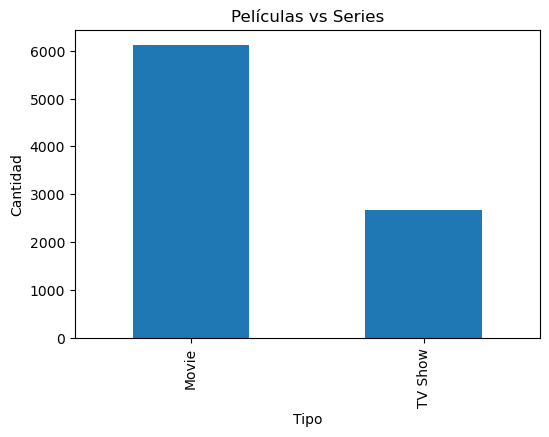

In [22]:
plt.figure(figsize=(6,4))
df['type'].value_counts().plot(kind='bar')
plt.title('Películas vs Series')
plt.xlabel('Tipo')
plt.ylabel('Cantidad')
plt.show()

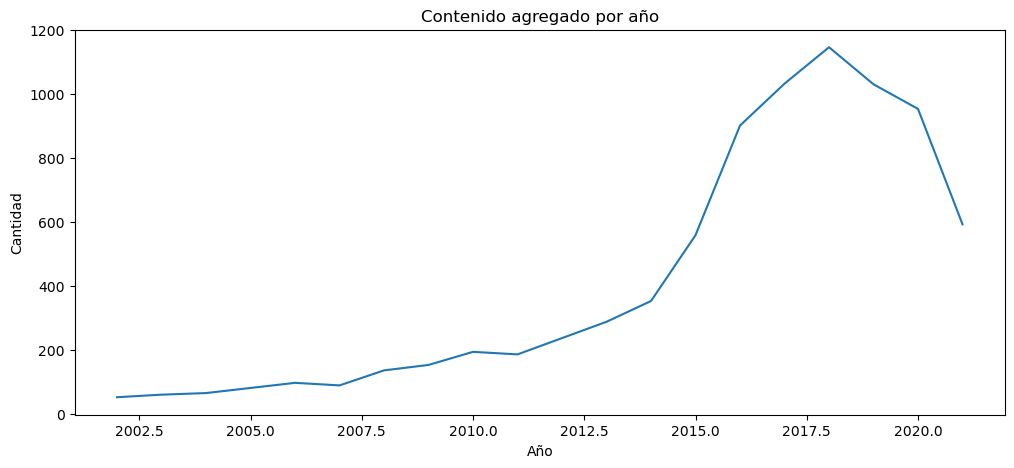

In [23]:
plt.figure(figsize=(12,5))
df['release_year'].value_counts().sort_index().tail(20).plot()
plt.title('Contenido agregado por año')
plt.xlabel('Año')
plt.ylabel('Cantidad')
plt.show()

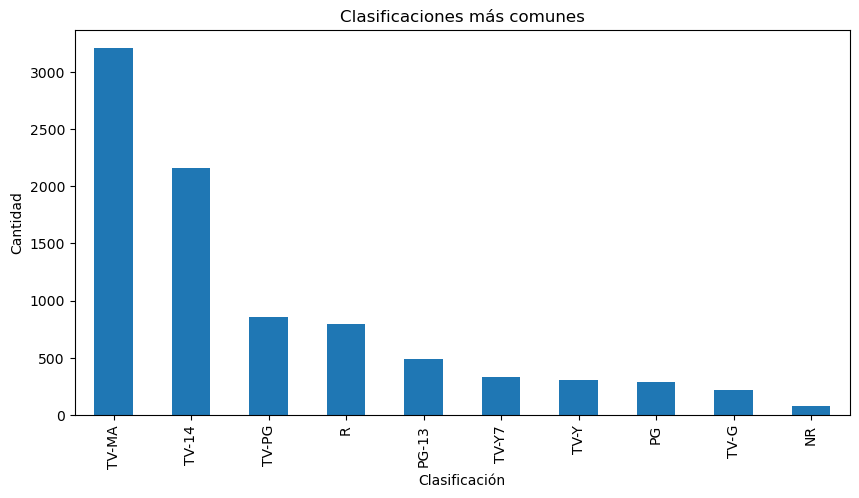

In [24]:
plt.figure(figsize=(10,5))
df['rating'].value_counts().head(10).plot(kind='bar')
plt.title('Clasificaciones más comunes')
plt.xlabel('Clasificación')
plt.ylabel('Cantidad')
plt.show()

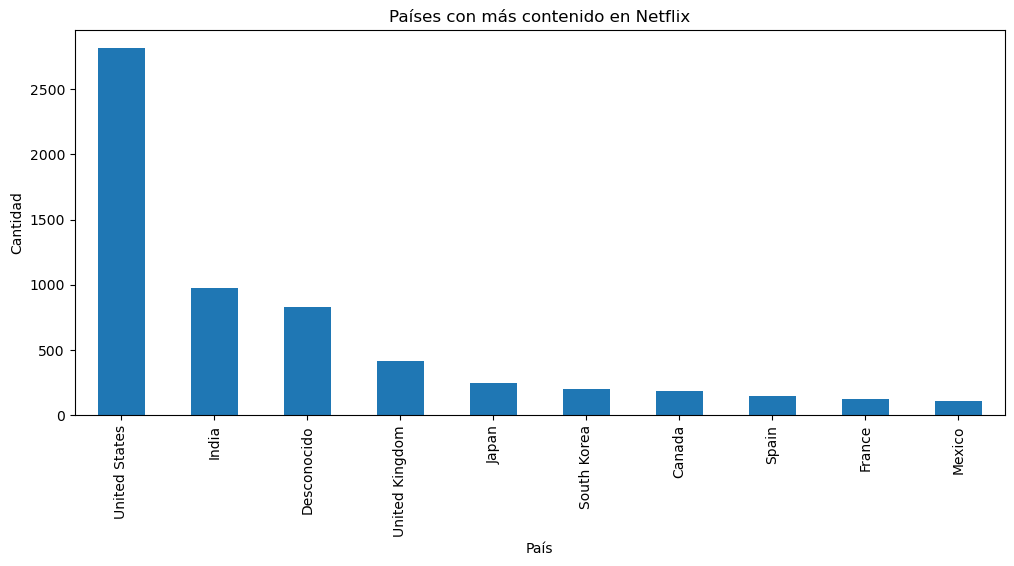

In [26]:
plt.figure(figsize=(12,5))
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Países con más contenido en Netflix')
plt.xlabel('País')
plt.ylabel('Cantidad')
plt.show()

//POR UTLIMA FASE, SE IDENTIFICA EL WISDOM
Conlusiones:

1. Netflix tiene más películas que series de televisión.

2. La mayoría del contenido fue agregado entre 2016 y 2021,
lo que muestra un crecimiento acelerado de la plataforma.

3. Estados Unidos es el país con mayor cantidad de contenido.

4. La clasificación TV-MA es una de las más comunes,
indicando que gran parte del contenido está dirigido a adultos.